HARSHINI J
2025AC05202

In [15]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns



## Dataset Description

The Dry Bean Dataset is a multiclass classification dataset obtained
from the UCI Machine Learning Repository.

The dataset contains geometric measurements of dry bean samples.

There are 16 numerical predictor variables:

- Area
- Perimeter
- MajorAxisLength
- MinorAxisLength
- AspectRatio
- Eccentricity
- ConvexArea
- EquivDiameter
- Extent
- Solidity
- roundness
- Compactness
- ShapeFactor1
- ShapeFactor2
- ShapeFactor3
- ShapeFactor4

The target variable is `Class`.

The target contains seven bean varieties:

- SEKER
- BARBUNYA
- BOMBAY
- CALI
- HOROZ
- DERMASON
- SIRA

In [16]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Class"

DATA_PATH = "./data/Dry_Bean_Dataset.xlsx"

MODEL_DIR = "."
OUTPUT_DIR = "./outputs"

TEST_DATA_PATH = "./test_data.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)
# Load the original UCI Dry Bean dataset

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("First five rows:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset loaded successfully.
Dataset shape: (13611, 17)
First five rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  obj

In [17]:
print("Number of instances:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Number of features:", df.shape[1] - 1)
print("Number of classes:", df[TARGET].nunique())

print("\nTarget classes:")
print(sorted(df[TARGET].unique()))

Number of instances: 13611
Number of columns: 17
Number of features: 16
Number of classes: 7

Target classes:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [18]:
missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values)

print("\nTotal missing values:", missing_values.sum())
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print("Dataset shape after duplicate handling:", df.shape)
class_counts = df[TARGET].value_counts()

print("Class distribution:")
display(class_counts)

Missing values by column:


,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0



Total missing values: 0
Number of duplicate rows: 68
Duplicates removed.
Dataset shape after duplicate handling: (13543, 17)
Class distribution:


,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1860
CALI,1630
BARBUNYA,1322
BOMBAY,522


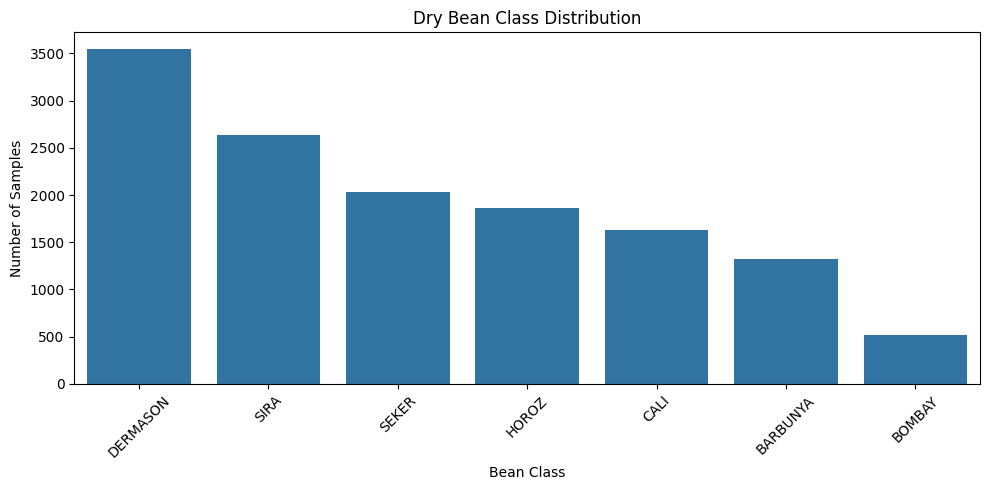

In [19]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x=TARGET,
    order=df[TARGET].value_counts().index
)

plt.title("Dry Bean Class Distribution")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())
non_numeric_columns = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

if len(non_numeric_columns) == 0:
    print("All 16 predictor variables are numerical.")
else:
    print("Non-numeric columns found:")
    print(non_numeric_columns)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Feature matrix shape: (13543, 16)
Target shape: (13543,)

Feature columns:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
All 16 predictor variables are numerical.
Training samples: 10834
Testing samples: 2709

Training feature shape: (10834, 16)
Testing feature shape: (2709, 16)


## Preprocessing Strategy

The dataset contains only numerical predictor variables, so no
categorical encoding is required.

The following preprocessing strategy is used:

1. The target variable `Class` is separated from the predictors.
2. The dataset is divided into 80% training and 20% testing data.
3. Stratified sampling is used to preserve the class distribution.
4. StandardScaler is applied to Logistic Regression, KNN, and
   Gaussian Naive Bayes.
5. Decision Tree and Random Forest are trained without scaling
   because tree-based algorithms are not sensitive to feature scale.
6. Scaling is performed inside a Pipeline so that the scaler is
   fitted only on the training data, preventing data leakage.

In [21]:
test_data = X_test.copy()

test_data[TARGET] = y_test.values

test_data.to_csv(
    TEST_DATA_PATH,
    index=False
)

print("Test data saved successfully.")
print("Location:", TEST_DATA_PATH)
print("Shape:", test_data.shape)

display(test_data.head())

Test data saved successfully.
Location: ./test_data.csv
Shape: (2709, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
1223,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,0.935641,0.915043,0.006127,0.002650,0.837304,0.996621,SEKER
11769,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,0.918153,0.804670,0.007853,0.002031,0.647494,0.997670,DERMASON
12059,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,0.921638,0.838940,0.007392,0.002259,0.703820,0.995990,DERMASON
7126,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,0.799130,0.680021,0.006681,0.000881,0.462428,0.995303,HOROZ
638,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,0.953047,0.894217,0.006543,0.002581,0.799623,0.998322,SEKER


In [22]:
models = {

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Decision Tree": Pipeline([
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]),

    "KNN": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]),

    "Naive Bayes": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            GaussianNB()
        )
    ]),

    "Random Forest": Pipeline([
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])
}

print("Five classification models defined:")
for name in models:
    print("-", name)

Five classification models defined:
- Logistic Regression
- Decision Tree
- KNN
- Naive Bayes
- Random Forest


In [23]:
trained_models = {}

for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[model_name] = model

    print(f"{model_name} training completed.")

print("\nAll models trained successfully.")


Training Logistic Regression...
Logistic Regression training completed.

Training Decision Tree...
Decision Tree training completed.

Training KNN...
KNN training completed.

Training Naive Bayes...
Naive Bayes training completed.

Training Random Forest...
Random Forest training completed.

All models trained successfully.


In [24]:
results = {}

predictions = {}

probabilities = {}

for model_name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Class probabilities
    y_proba = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results[model_name] = {
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    }

    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba

results_df = pd.DataFrame(
    results
).T.reset_index()

results_df = results_df.rename(
    columns={"index": "ML Model Name"}
)

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

results_display = results_df.copy()

results_display[
    metric_columns
] = results_display[
    metric_columns
].round(4)

display(results_display)
results_df.to_csv(
    "./outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved to:")
print("./outputs/model_comparison.csv")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9192,0.9934,0.9197,0.9192,0.9193,0.9023
1,Decision Tree,0.8966,0.9363,0.8965,0.8966,0.8964,0.8750
2,KNN,0.9155,0.9811,0.9163,0.9155,0.9157,0.8978
3,Naive Bayes,0.8970,0.9899,0.8997,0.8970,0.8972,0.8762
4,Random Forest,0.9199,0.9907,0.9199,0.9199,0.9198,0.9031


Model comparison saved to:
./outputs/model_comparison.csv


In [25]:
model_file_names = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "KNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, file_name in model_file_names.items():

    file_path = os.path.join(
        MODEL_DIR,
        file_name
    )

    joblib.dump(
        trained_models[model_name],
        file_path
    )

    print(
        f"Saved: {file_path}"
    )

Saved: ./logistic_regression.pkl
Saved: ./decision_tree.pkl
Saved: ./knn.pkl
Saved: ./naive_bayes.pkl
Saved: ./random_forest.pkl


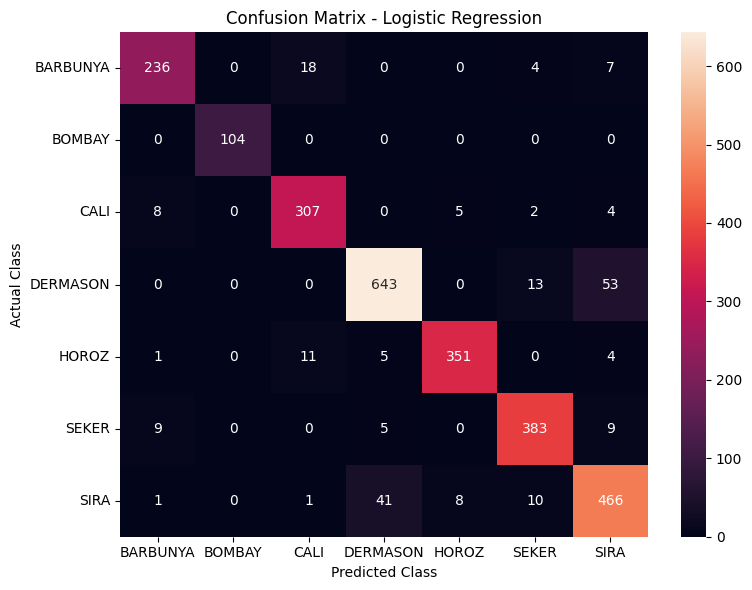

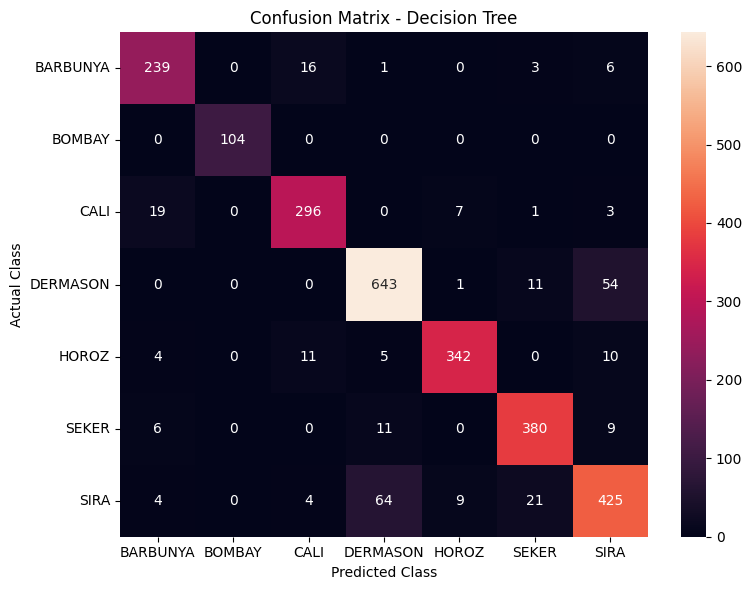

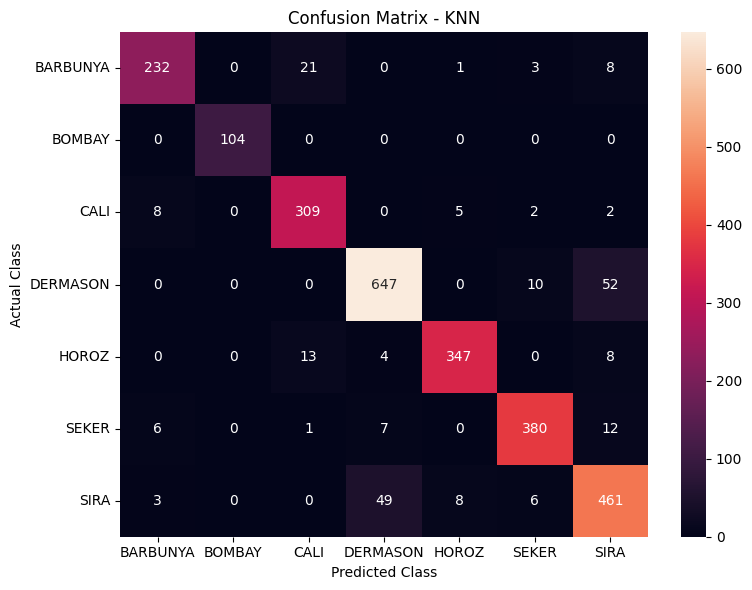

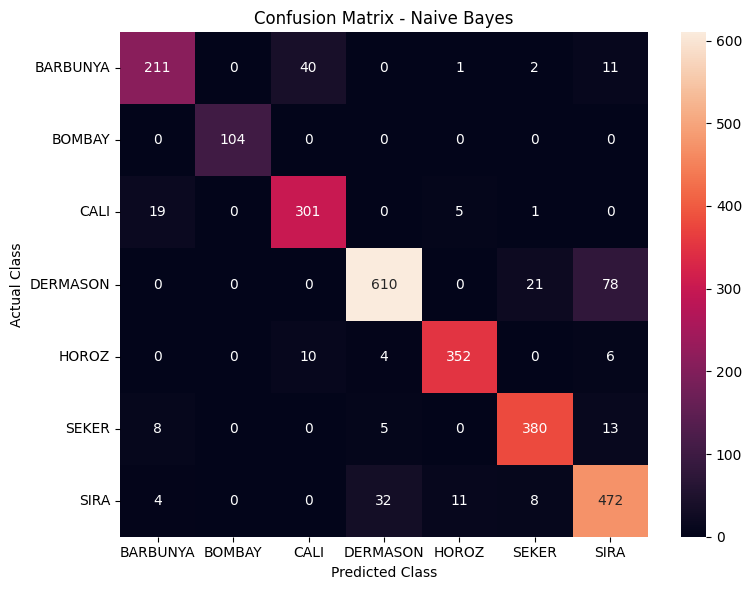

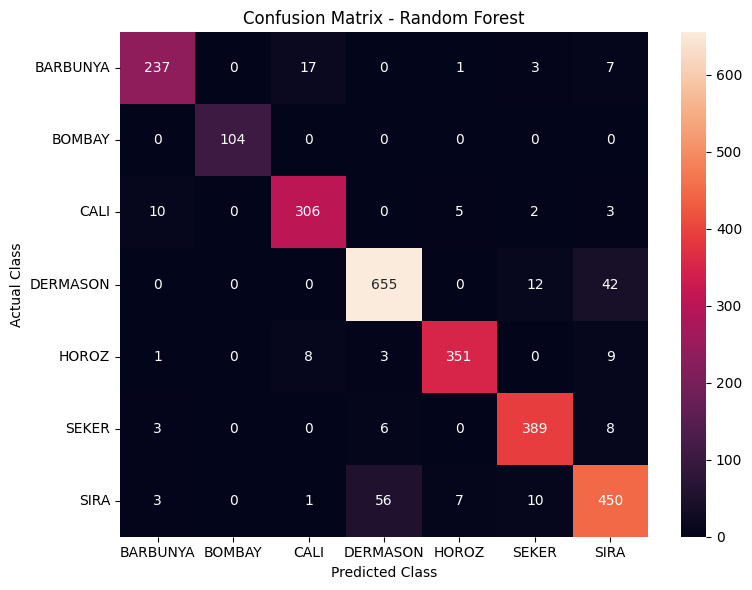

In [26]:
class_names = sorted(
    y_test.unique()
)

for model_name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_names
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

In [27]:
for model_name, y_pred in predictions.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.90      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.91      0.91       326
    DERMASON       0.89      0.91      0.90       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.91      0.94      0.9

In [28]:
winner_row = results_df.loc[
    results_df["F1"].idxmax()
]

print("Overall Best Model Based on F1 Score")
print("-" * 40)

print(
    "Model:",
    winner_row["ML Model Name"]
)

print(
    "Accuracy:",
    f"{winner_row['Accuracy']:.4f}"
)

print(
    "AUC:",
    f"{winner_row['AUC']:.4f}"
)

print(
    "Precision:",
    f"{winner_row['Precision']:.4f}"
)

print(
    "Recall:",
    f"{winner_row['Recall']:.4f}"
)

print(
    "F1:",
    f"{winner_row['F1']:.4f}"
)

print(
    "MCC:",
    f"{winner_row['MCC']:.4f}"
)

Overall Best Model Based on F1 Score
----------------------------------------
Model: Random Forest
Accuracy: 0.9199
AUC: 0.9907
Precision: 0.9199
Recall: 0.9199
F1: 0.9198
MCC: 0.9031
